# Customer Churn Prediction

## Objective
The goal of this project is to build a machine learning model that predicts whether a customer will churn (leave the service) based on their features.

## Dataset
Telco Customer Churn Dataset (Kaggle)

## Tools & Libraries
- Python
- Pandas, NumPy
- Scikit-learn
- Matplotlib / Seaborn

In [189]:
import pandas as pd

# Load the dataset
df = pd.read_csv('churn.csv')

# View the first 5 rows to confirm it worked
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## Data Overview
Let's check the structure and data types

In [190]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Cleaning

We fix:
- Wrong data types
- Missing values
- Unnecessary columns

In [191]:

# Consolidate preprocessing
df = pd.read_csv('churn.csv')
df = df.drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df["SeniorCitizen"] = df["SeniorCitizen"].astype("category")

# Create tenure groups BEFORE dummy encoding
df["tenure_group"] = pd.cut(df["tenure"], bins=[0,12,24,48,60,72], labels=["0-1y","1-2y","2-4y","4-5y","5-6y"])

# Call get_dummies ONLY ONCE
df = pd.get_dummies(df, drop_first=True)

# Ensure no duplicate columns remain
df = df.loc[:, ~df.columns.duplicated()]

## Data Exploration

Check how many customers churned

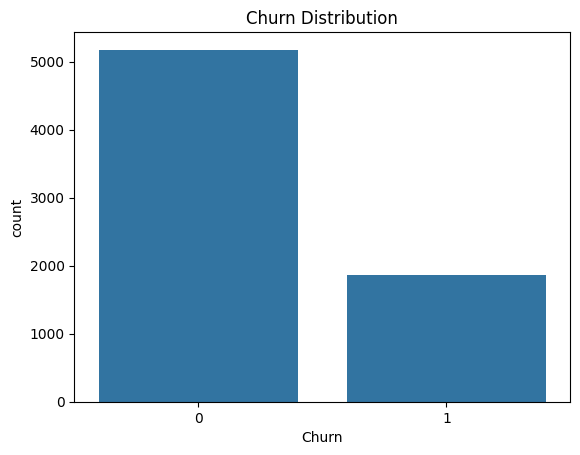

In [192]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

### Check important features

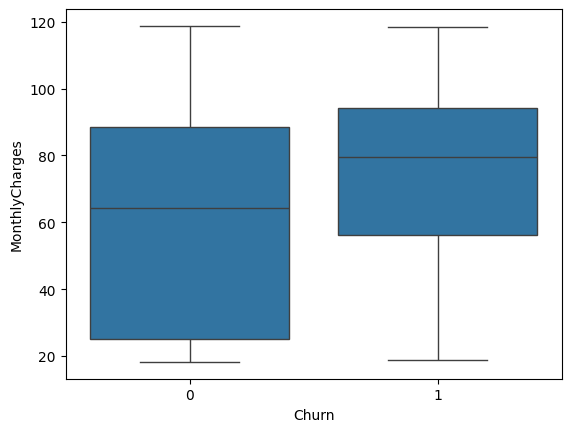

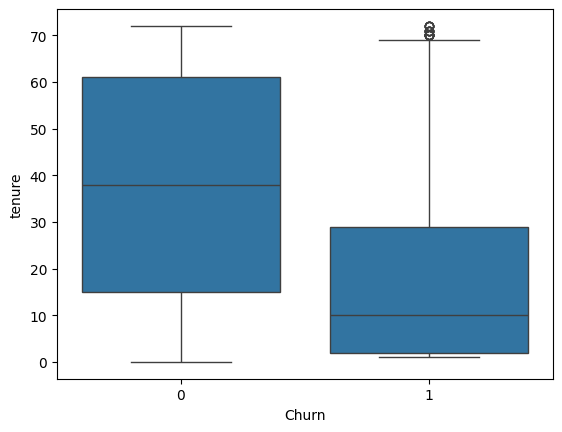

In [193]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

## Feature Engineering

We create better features for the model

## Convert text data into numbers

## Model Training

In [194]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Result

In [195]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }
    
    # ROC-AUC (only if model supports predict_proba)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        results["ROC-AUC"] = roc_auc_score(y_test, y_prob)
    
    return results

In [196]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7955997161107168
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.80      0.79      1409



In [197]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train, y_train)

lr_results = evaluate_model(lr_model, X_test, y_test)
print("Logistic Regression:", lr_results)

Logistic Regression: {'Accuracy': 0.7984386089425124, 'Precision': 0.65, 'Recall': 0.5213903743315508, 'F1': 0.5786350148367952, 'ROC-AUC': 0.8422873233614921}


In [198]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(rf_model, X_test, y_test)
print("Random Forest:", rf_results)

Random Forest: {'Accuracy': 0.7863733144073811, 'Precision': 0.6237288135593221, 'Recall': 0.4919786096256685, 'F1': 0.5500747384155455, 'ROC-AUC': 0.8226381461675579}


In [199]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [200]:
import numpy as np
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb.fit(np.array(X_train), np.array(y_train))

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [201]:
from xgboost import XGBClassifier

# Initialize the model
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

# Fit the model
xgb.fit(X_train, y_train)

# Calculate results so they can be used in the comparison table later
xgb_results = evaluate_model(xgb, X_test, y_test)
print("XGBoost Results:", xgb_results)

XGBoost Results: {'Accuracy': 0.7856635911994322, 'Precision': 0.6125, 'Recall': 0.5240641711229946, 'F1': 0.5648414985590778, 'ROC-AUC': 0.8223203906068357}


In [202]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=100,
    random_state=42
)

lgb_model.fit(X_train, y_train)

lgb_results = evaluate_model(lgb_model, X_test, y_test)
print("LightGBM:", lgb_results)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000264 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 645
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
LightGBM: {'Accuracy': 0.7927608232789212, 'Precision': 0.6339869281045751, 'Recall': 0.5187165775401069, 'F1': 0.5705882352941176, 'ROC-AUC': 0.837942080653078}


In [203]:
import pandas as pd

results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results,
    lgb_results,
    ], index=["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"])

print(results_df)

                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.798439   0.650000  0.521390  0.578635  0.842287
Random Forest        0.786373   0.623729  0.491979  0.550075  0.822638
XGBoost              0.785664   0.612500  0.524064  0.564841  0.822320
LightGBM             0.792761   0.633987  0.518717  0.570588  0.837942


I compared all models together and selected the better-performing model

## Hyperparameter Tuning ( All Models)

### Logistic Regrition

In [204]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Define the model
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

# 2. Fit the model
lr_model.fit(X_train, y_train)

# 3. GENERATE PREDICTIONS (This is the missing step!)
y_pred_lr = lr_model.predict(X_test)

# 4. Evaluate
lr_results = evaluate_model(lr_model, X_test, y_test)
print("Logistic Regression:", lr_results)

Logistic Regression: {'Accuracy': 0.7984386089425124, 'Precision': 0.65, 'Recall': 0.5213903743315508, 'F1': 0.5786350148367952, 'ROC-AUC': 0.8422873233614921}


### Random Forest tuning

In [205]:
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=3,
    scoring="f1"
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)

Best RF params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


### XGBoost tuning

In [206]:
from xgboost import XGBClassifier

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    xgb_param_grid,
    cv=3,
    scoring="f1"
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
print("Best XGB params:", xgb_grid.best_params_)

Best XGB params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}


### ROC Curve Comparison

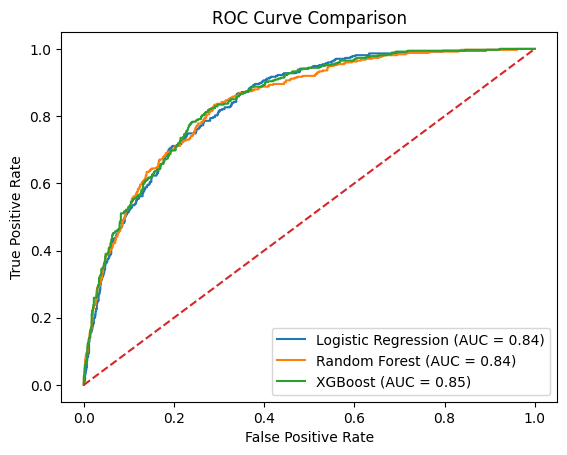

In [207]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [208]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

model = best_xgb  # usually best model
y_prob = model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    results.append((t, precision, recall))

for t, p, r in results:
    print(f"Threshold: {t:.2f} | Precision: {p:.2f} | Recall: {r:.2f}")

Threshold: 0.10 | Precision: 0.40 | Recall: 0.94
Threshold: 0.15 | Precision: 0.44 | Recall: 0.91
Threshold: 0.20 | Precision: 0.48 | Recall: 0.85
Threshold: 0.25 | Precision: 0.51 | Recall: 0.82
Threshold: 0.30 | Precision: 0.53 | Recall: 0.79
Threshold: 0.35 | Precision: 0.55 | Recall: 0.72
Threshold: 0.40 | Precision: 0.59 | Recall: 0.64
Threshold: 0.45 | Precision: 0.62 | Recall: 0.60
Threshold: 0.50 | Precision: 0.65 | Recall: 0.53
Threshold: 0.55 | Precision: 0.70 | Recall: 0.45
Threshold: 0.60 | Precision: 0.74 | Recall: 0.36
Threshold: 0.65 | Precision: 0.78 | Recall: 0.29
Threshold: 0.70 | Precision: 0.80 | Recall: 0.23
Threshold: 0.75 | Precision: 0.80 | Recall: 0.16
Threshold: 0.80 | Precision: 0.82 | Recall: 0.13
Threshold: 0.85 | Precision: 0.89 | Recall: 0.04


In [209]:
best_threshold = 0.3  # example threshold based on results

y_pred_custom = (y_prob >= best_threshold).astype(int)

## Threshold Optimization

The default classification threshold (0.5) resulted in low recall (~0.52), meaning many churners were not identified.

By lowering the threshold to 0.30:
- Recall improved to ~0.76
- Precision remained acceptable (~0.52)

This adjustment significantly improves the model’s ability to detect customers at risk of churn, which is critical in business applications where missing a churner is costly.

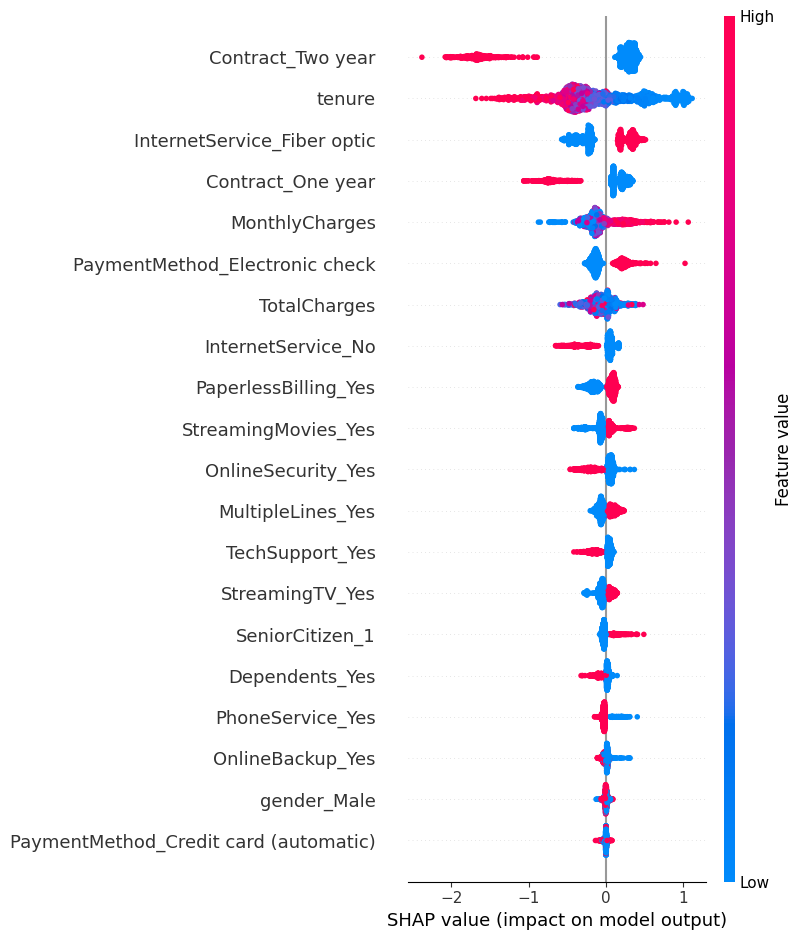

In [210]:
import shap

explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

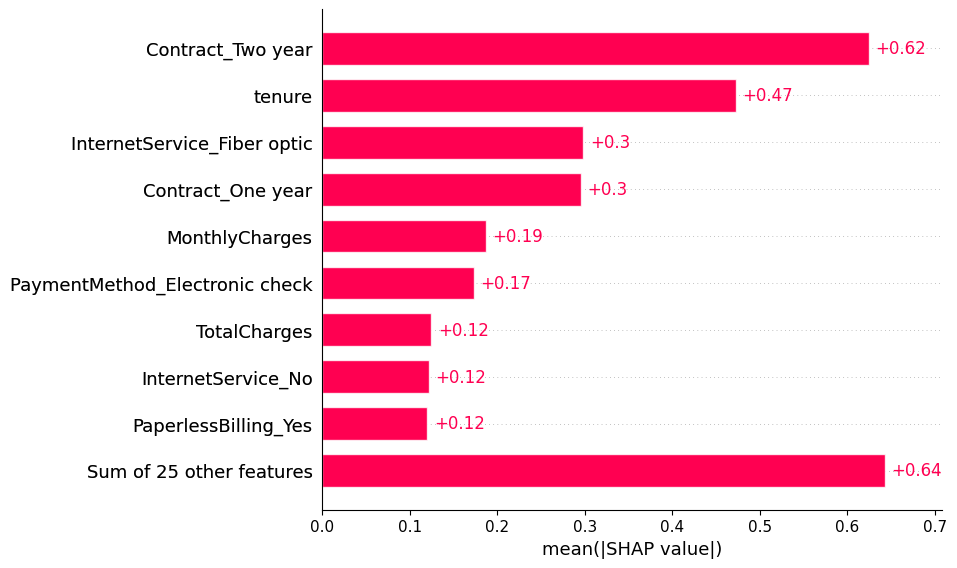

In [211]:
shap.plots.bar(shap_values)

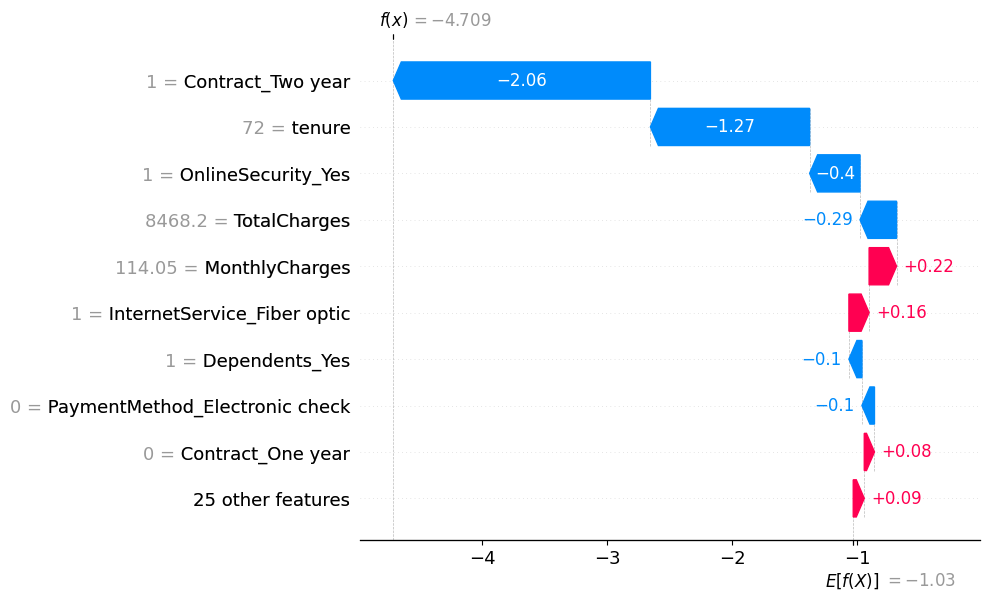

In [212]:
shap.plots.waterfall(shap_values[0])

## Model Explainability (SHAP)

SHAP was used to interpret the XGBoost model and understand feature impact.

Key insights:
- Contract type is the strongest predictor of churn
- Higher monthly charges increase churn probability
- Customers with shorter tenure are more likely to churn

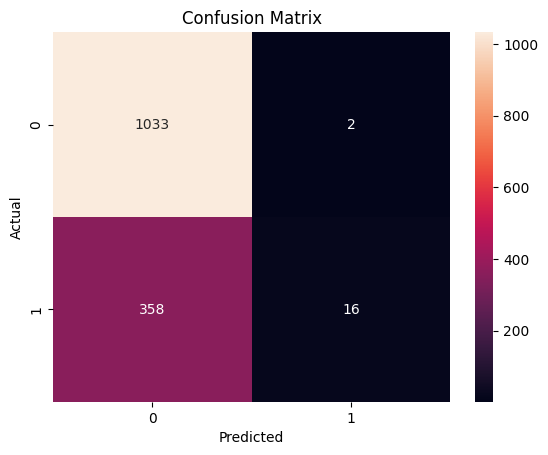

In [213]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [214]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Random Forest Accuracy: 0.7444996451383961
Logistic Regression Accuracy: 0.7984386089425124


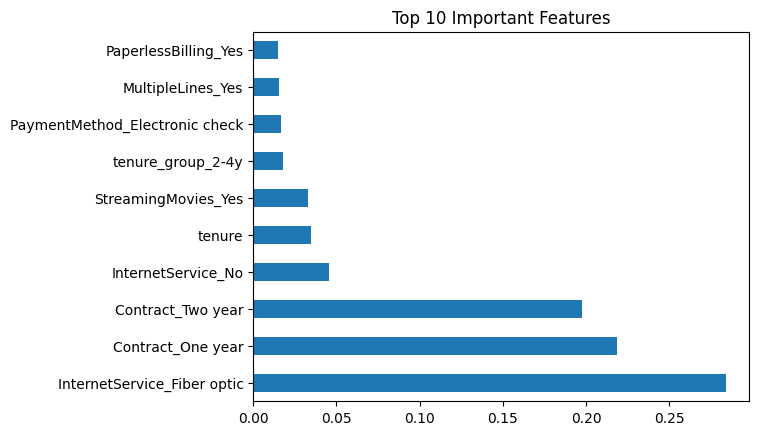

In [215]:
importances = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

In [216]:
model_balanced = RandomForestClassifier(class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print("Balanced Accuracy:", accuracy_score(y_test, y_pred_balanced))

Balanced Accuracy: 0.7913413768630234


In [217]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 50}


## Conclusion

- Random Forest and Logistic Regression models were trained and evaluated
- Random Forest performed better with higher accuracy
- Important features influencing churn included contract type, monthly charges, and tenure
- The model can help businesses identify high-risk customers and take preventive actions